<a href="https://colab.research.google.com/github/djtheconqueror/home_ai/blob/main/BioPure_AI_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BioPure AI v1

BioPure AI is an early-stage machine learning project focused on predicting protein purification outcomes from synthetic bioprocess conditions.

The model estimates purification yield, success likelihood, and quality tier based on lab-process variables such as pH, temperature, flow rate, protein concentration, buffer type, column type, impurity level, and runtime.

In [2]:
!pip install scikit-learn pandas numpy matplotlib joblib --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

In [3]:
rng = np.random.default_rng(42)
n = 900

buffer_types = ["PBS", "Tris", "HEPES", "Acetate"]
column_types = ["Affinity", "Ion Exchange", "Size Exclusion", "Hydrophobic"]

data = pd.DataFrame({
    "pH": rng.uniform(4.5, 9.0, n),
    "temperature_c": rng.uniform(4, 37, n),
    "flow_rate_ml_min": rng.uniform(0.2, 5.0, n),
    "protein_concentration_mg_ml": rng.uniform(0.1, 10.0, n),
    "initial_purity": rng.uniform(0.25, 0.95, n),
    "impurity_level": rng.uniform(0.05, 0.80, n),
    "runtime_min": rng.uniform(20, 180, n),
    "buffer_type": rng.choice(buffer_types, n),
    "column_type": rng.choice(column_types, n),
})

# Synthetic process logic
# These are not real lab equations — they create realistic-looking patterns for a prototype.

optimal_pH_bonus = 1 - np.abs(data["pH"] - 7.2) / 4.5
optimal_pH_bonus = np.clip(optimal_pH_bonus, 0, 1)

temp_penalty = np.clip((data["temperature_c"] - 20) / 25, 0, 1)

flow_penalty = np.clip((data["flow_rate_ml_min"] - 2.5) / 3.0, 0, 1)

concentration_bonus = np.clip(data["protein_concentration_mg_ml"] / 10, 0, 1)

purity_bonus = data["initial_purity"]

impurity_penalty = data["impurity_level"]

runtime_bonus = np.clip(data["runtime_min"] / 120, 0, 1)
runtime_penalty = np.clip((data["runtime_min"] - 140) / 80, 0, 1)

column_effect = data["column_type"].map({
    "Affinity": 0.12,
    "Ion Exchange": 0.08,
    "Size Exclusion": 0.05,
    "Hydrophobic": 0.02,
})

buffer_effect = data["buffer_type"].map({
    "PBS": 0.04,
    "Tris": 0.06,
    "HEPES": 0.05,
    "Acetate": -0.03,
})

noise = rng.normal(0, 0.04, n)

yield_score = (
    0.28 * optimal_pH_bonus +
    0.18 * purity_bonus +
    0.14 * concentration_bonus +
    0.12 * runtime_bonus -
    0.14 * impurity_penalty -
    0.08 * temp_penalty -
    0.06 * flow_penalty -
    0.04 * runtime_penalty +
    column_effect +
    buffer_effect +
    noise
)

data["predicted_yield"] = np.clip(yield_score, 0, 1)

data["success"] = (data["predicted_yield"] >= 0.62).astype(int)

data["quality_tier"] = pd.cut(
    data["predicted_yield"],
    bins=[-0.01, 0.45, 0.70, 1.01],
    labels=["Low", "Medium", "High"]
)

data.head()

,pH,temperature_c,flow_rate_ml_min,protein_concentration_mg_ml,initial_purity,impurity_level,runtime_min,buffer_type,column_type,predicted_yield,success,quality_tier
0,7.982802,19.457749,3.129610,6.918647,0.450785,0.064139,129.090676,Acetate,Affinity,0.628417,1,Medium
1,6.474953,12.561515,3.193023,5.374130,0.341017,0.391266,52.192720,PBS,Affinity,0.516736,0,Medium
2,8.363691,5.490713,0.848383,3.939854,0.600846,0.513555,81.473281,Acetate,Ion Exchange,0.490141,0,Medium
3,7.638156,19.889214,3.528994,8.141740,0.404034,0.395297,43.446236,Tris,Ion Exchange,0.598608,0,Medium
4,4.923798,35.657967,3.438802,7.124628,0.904886,0.147984,108.440167,Acetate,Affinity,0.517714,0,Medium


In [4]:
feature_cols_numeric = [
    "pH",
    "temperature_c",
    "flow_rate_ml_min",
    "protein_concentration_mg_ml",
    "initial_purity",
    "impurity_level",
    "runtime_min",
]

categorical_cols = ["buffer_type", "column_type"]

model_data = pd.get_dummies(
    data,
    columns=categorical_cols,
    drop_first=False
)

feature_cols = [
    col for col in model_data.columns
    if col not in ["predicted_yield", "success", "quality_tier"]
]

X = model_data[feature_cols]
y_yield = model_data["predicted_yield"]
y_success = model_data["success"]
y_quality = model_data["quality_tier"]

X.head()

,pH,temperature_c,flow_rate_ml_min,protein_concentration_mg_ml,initial_purity,impurity_level,runtime_min,buffer_type_Acetate,buffer_type_HEPES,buffer_type_PBS,buffer_type_Tris,column_type_Affinity,column_type_Hydrophobic,column_type_Ion Exchange,column_type_Size Exclusion
0,7.982802,19.457749,3.129610,6.918647,0.450785,0.064139,129.090676,True,False,False,False,True,False,False,False
1,6.474953,12.561515,3.193023,5.374130,0.341017,0.391266,52.192720,False,False,True,False,True,False,False,False
2,8.363691,5.490713,0.848383,3.939854,0.600846,0.513555,81.473281,True,False,False,False,False,False,True,False
3,7.638156,19.889214,3.528994,8.141740,0.404034,0.395297,43.446236,False,False,False,True,False,False,True,False
4,4.923798,35.657967,3.438802,7.124628,0.904886,0.147984,108.440167,True,False,False,False,True,False,False,False


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_yield,
    test_size=0.2,
    random_state=42
)

yield_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=7,
    random_state=42
)

yield_model.fit(X_train, y_train)

y_pred = yield_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.051474010580726016
R² Score: 0.637133023971961


In [6]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_success,
    test_size=0.2,
    random_state=42,
    stratify=y_success
)

success_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=7,
    random_state=42,
    class_weight="balanced"
)

success_model.fit(X_train_c, y_train_c)

success_pred = success_model.predict(X_test_c)

print(classification_report(y_test_c, success_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       163
           1       0.55      0.35      0.43        17

    accuracy                           0.91       180
   macro avg       0.74      0.66      0.69       180
weighted avg       0.90      0.91      0.90       180



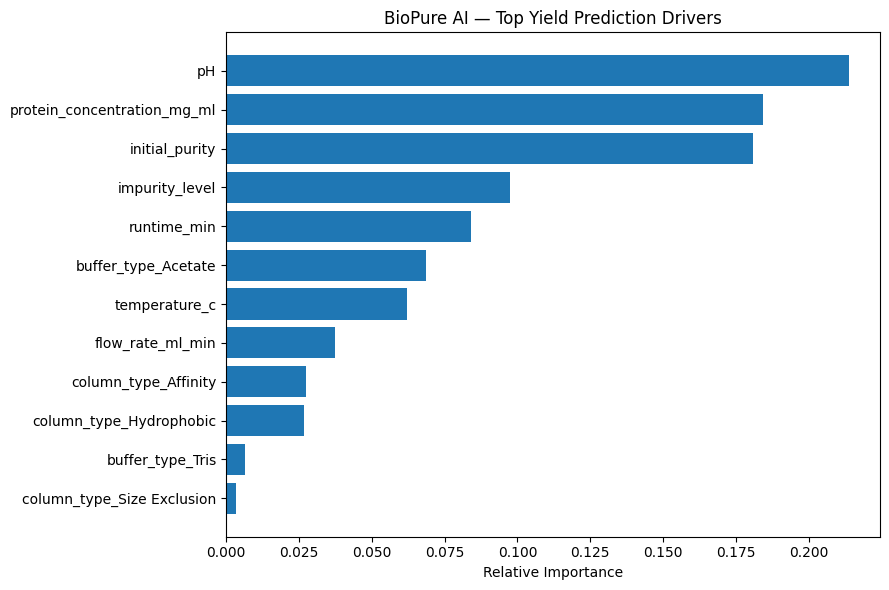

In [7]:
importances = yield_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=True).tail(12)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("BioPure AI — Top Yield Prediction Drivers")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [8]:
def prepare_sample(sample_dict):
    sample_df = pd.DataFrame([sample_dict])

    sample_encoded = pd.get_dummies(sample_df)

    # Add missing training columns
    for col in feature_cols:
        if col not in sample_encoded.columns:
            sample_encoded[col] = 0

    # Keep exact same column order
    sample_encoded = sample_encoded[feature_cols]

    return sample_encoded


def quality_from_yield(yield_score):
    if yield_score >= 0.70:
        return "High"
    elif yield_score >= 0.45:
        return "Medium"
    else:
        return "Low"


def biopure_predict(sample_dict):
    x = prepare_sample(sample_dict)

    predicted_yield = float(yield_model.predict(x)[0])
    success_prob = float(success_model.predict_proba(x)[0, 1])
    success_label = int(success_prob >= 0.5)
    quality_tier = quality_from_yield(predicted_yield)

    bullets = []

    if abs(sample_dict["pH"] - 7.2) <= 0.5:
        bullets.append("pH is close to the preferred operating range.")
    else:
        bullets.append("pH is outside the ideal range and may reduce yield.")

    if sample_dict["temperature_c"] > 25:
        bullets.append("Elevated temperature may increase instability or degradation risk.")

    if sample_dict["impurity_level"] > 0.45:
        bullets.append("High impurity level is likely reducing purification quality.")

    if sample_dict["initial_purity"] > 0.70:
        bullets.append("Strong initial purity supports a better final outcome.")

    if sample_dict["flow_rate_ml_min"] > 3.5:
        bullets.append("High flow rate may reduce binding/contact efficiency.")

    if sample_dict["runtime_min"] > 140:
        bullets.append("Long runtime may improve separation but can add stability risk.")

    if not bullets:
        bullets.append("Most process variables are within acceptable prototype ranges.")

    explanation = {
        "summary": f"BioPure AI predicts {predicted_yield:.1%} yield with {quality_tier} quality.",
        "predicted_yield": predicted_yield,
        "success_probability": success_prob,
        "success_label": success_label,
        "quality_tier": quality_tier,
        "bullets": bullets,
    }

    return predicted_yield, success_prob, quality_tier, explanation

In [9]:
sample_run = {
    "pH": 7.1,
    "temperature_c": 18,
    "flow_rate_ml_min": 1.8,
    "protein_concentration_mg_ml": 6.5,
    "initial_purity": 0.78,
    "impurity_level": 0.18,
    "runtime_min": 95,
    "buffer_type": "Tris",
    "column_type": "Affinity",
}

predicted_yield, success_prob, quality_tier, explanation = biopure_predict(sample_run)

print("=== BioPure AI Report ===")
print(explanation["summary"])
print()
print(f"Predicted Yield: {predicted_yield:.2%}")
print(f"Success Probability: {success_prob:.2%}")
print(f"Quality Tier: {quality_tier}")
print()
print("Key Factors:")
for bullet in explanation["bullets"]:
    print("•", bullet)

=== BioPure AI Report ===
BioPure AI predicts 64.0% yield with Medium quality.

Predicted Yield: 63.99%
Success Probability: 89.67%
Quality Tier: Medium

Key Factors:
• pH is close to the preferred operating range.
• Strong initial purity supports a better final outcome.


In [10]:
scenarios = {
    "Optimal Affinity Run": {
        "pH": 7.1,
        "temperature_c": 18,
        "flow_rate_ml_min": 1.5,
        "protein_concentration_mg_ml": 7.2,
        "initial_purity": 0.82,
        "impurity_level": 0.12,
        "runtime_min": 90,
        "buffer_type": "Tris",
        "column_type": "Affinity",
    },
    "High Impurity Run": {
        "pH": 6.8,
        "temperature_c": 22,
        "flow_rate_ml_min": 2.8,
        "protein_concentration_mg_ml": 4.5,
        "initial_purity": 0.46,
        "impurity_level": 0.68,
        "runtime_min": 110,
        "buffer_type": "PBS",
        "column_type": "Ion Exchange",
    },
    "Poor pH Control": {
        "pH": 4.9,
        "temperature_c": 20,
        "flow_rate_ml_min": 2.0,
        "protein_concentration_mg_ml": 5.8,
        "initial_purity": 0.62,
        "impurity_level": 0.32,
        "runtime_min": 100,
        "buffer_type": "Acetate",
        "column_type": "Size Exclusion",
    },
    "Temperature-Stressed Run": {
        "pH": 7.4,
        "temperature_c": 34,
        "flow_rate_ml_min": 2.3,
        "protein_concentration_mg_ml": 6.2,
        "initial_purity": 0.70,
        "impurity_level": 0.25,
        "runtime_min": 130,
        "buffer_type": "HEPES",
        "column_type": "Affinity",
    },
}

In [11]:
def score_biopure_scenarios(scenarios):
    rows = []

    for name, sample in scenarios.items():
        predicted_yield, success_prob, quality_tier, explanation = biopure_predict(sample)

        rows.append({
            "scenario": name,
            "predicted_yield": round(predicted_yield, 3),
            "success_probability": round(success_prob, 3),
            "quality_tier": quality_tier,
            "summary": explanation["summary"],
        })

    return pd.DataFrame(rows).sort_values("predicted_yield", ascending=False)

scenario_results = score_biopure_scenarios(scenarios)
scenario_results

,scenario,predicted_yield,success_probability,quality_tier,summary
0,Optimal Affinity Run,0.648,0.887,Medium,BioPure AI predicts 64.8% yield with Medium qu...
3,Temperature-Stressed Run,0.582,0.296,Medium,BioPure AI predicts 58.2% yield with Medium qu...
1,High Impurity Run,0.480,0.101,Medium,BioPure AI predicts 48.0% yield with Medium qu...
2,Poor pH Control,0.423,0.063,Low,BioPure AI predicts 42.3% yield with Low quality.


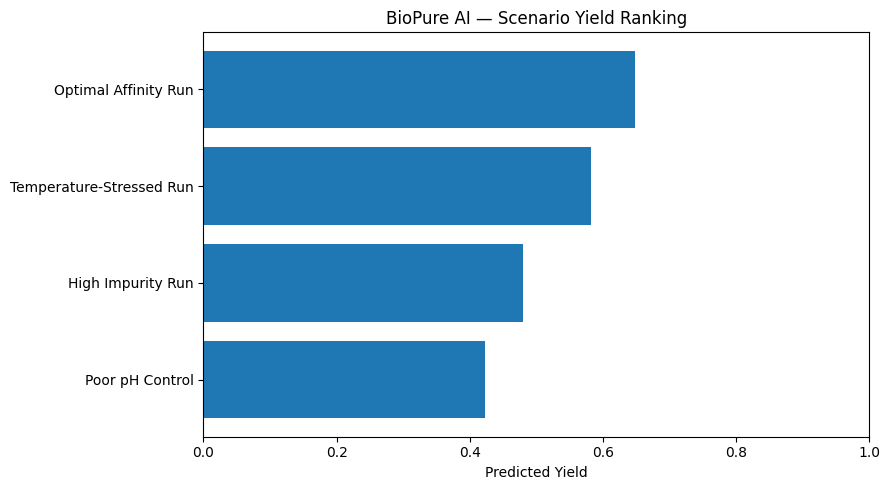

In [12]:
plt.figure(figsize=(9, 5))
plt.barh(
    scenario_results["scenario"],
    scenario_results["predicted_yield"]
)

plt.xlabel("Predicted Yield")
plt.title("BioPure AI — Scenario Yield Ranking")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
def executive_biopure_report(sample, name="Purification Run"):
    predicted_yield, success_prob, quality_tier, explanation = biopure_predict(sample)

    print("=" * 60)
    print(f"BIOPURE AI EXECUTIVE REPORT — {name}")
    print("=" * 60)
    print()
    print(f"Predicted Yield: {predicted_yield:.2%}")
    print(f"Success Probability: {success_prob:.2%}")
    print(f"Quality Tier: {quality_tier}")
    print()
    print("Summary:")
    print(explanation["summary"])
    print()
    print("Key Factors:")
    for bullet in explanation["bullets"]:
        print(f" - {bullet}")

    numeric_features = [
        "pH",
        "temperature_c",
        "flow_rate_ml_min",
        "protein_concentration_mg_ml",
        "initial_purity",
        "impurity_level",
        "runtime_min",
    ]

    df_sample = pd.DataFrame([sample])[numeric_features]

    plt.figure(figsize=(9, 4))
    df_sample.T[0].plot(kind="bar")
    plt.title(f"Process Feature Profile — {name}")
    plt.ylabel("Raw Value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

BIOPURE AI EXECUTIVE REPORT — Optimal Affinity Run

Predicted Yield: 64.78%
Success Probability: 88.69%
Quality Tier: Medium

Summary:
BioPure AI predicts 64.8% yield with Medium quality.

Key Factors:
 - pH is close to the preferred operating range.
 - Strong initial purity supports a better final outcome.


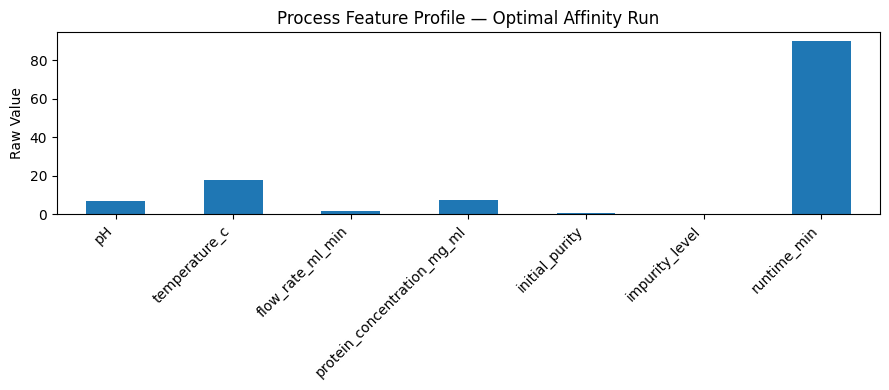

In [14]:
executive_biopure_report(
    scenarios["Optimal Affinity Run"],
    name="Optimal Affinity Run"
)

In [15]:
artifact = {
    "yield_model": yield_model,
    "success_model": success_model,
    "feature_cols": feature_cols,
}

joblib.dump(artifact, "biopure_ai_v1.pkl")

print("Saved model artifact: biopure_ai_v1.pkl")

Saved model artifact: biopure_ai_v1.pkl


In [16]:
print("BIOPURE AI v1 — PROJECT SUMMARY")
print("=" * 55)
print()
print("Purpose:")
print("BioPure AI predicts purification yield, success probability, and quality tier from synthetic bioprocess conditions.")
print()
print("Models:")
print("- RandomForestRegressor for predicted yield")
print("- RandomForestClassifier for purification success")
print()
print("Inputs:")
print("- pH")
print("- temperature")
print("- flow rate")
print("- protein concentration")
print("- initial purity")
print("- impurity level")
print("- runtime")
print("- buffer type")
print("- column type")
print()
print("Current Capabilities:")
print("- Synthetic purification dataset generation")
print("- Yield prediction")
print("- Success classification")
print("- Quality tier assignment")
print("- Scenario testing")
print("- Executive lab report")
print("- Feature importance visualization")
print("- Model artifact export")
print()
print("Portfolio Alignment:")
print("This project strengthens my applied AI portfolio by connecting biotechnology, lab-process optimization, and explainable machine learning.")
print()
print("Next Steps:")
print("- Add real or public bioprocess datasets")
print("- Build a Streamlit dashboard")
print("- Add model comparison")
print("- Add uncertainty estimates")
print("- Add experiment tracking")

BIOPURE AI v1 — PROJECT SUMMARY

Purpose:
BioPure AI predicts purification yield, success probability, and quality tier from synthetic bioprocess conditions.

Models:
- RandomForestRegressor for predicted yield
- RandomForestClassifier for purification success

Inputs:
- pH
- temperature
- flow rate
- protein concentration
- initial purity
- impurity level
- runtime
- buffer type
- column type

Current Capabilities:
- Synthetic purification dataset generation
- Yield prediction
- Success classification
- Quality tier assignment
- Scenario testing
- Executive lab report
- Feature importance visualization
- Model artifact export

Portfolio Alignment:
This project strengthens my applied AI portfolio by connecting biotechnology, lab-process optimization, and explainable machine learning.

Next Steps:
- Add real or public bioprocess datasets
- Build a Streamlit dashboard
- Add model comparison
- Add uncertainty estimates
- Add experiment tracking


In [17]:
scenario_results.to_csv("biopure_ai_scenario_report.csv", index=False)
print("Saved report: biopure_ai_scenario_report.csv")

Saved report: biopure_ai_scenario_report.csv


In [18]:
from google.colab import files

files.download("biopure_ai_v1.pkl")
files.download("biopure_ai_scenario_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>